In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('poems.csv')
df

,writer,poem,text
0,Лермонтов Михаил Юрьевич,Любовь мертвеца,NaN
1,Лермонтов Михаил Юрьевич,На серебряные шпоры…,На серебряные шпоры\nЯ в раздумии гляжу;\nЗа т...
2,Лермонтов Михаил Юрьевич,Вид гор из степей Козлова,Пилигрим\nАллах ли там среди пустыни\nЗастывши...
3,Лермонтов Михаил Юрьевич,"К (О, не скрывай! Ты плакала об нем…)","О, не скрывай! Ты плакала об нем –\nИ я его лю..."
4,Лермонтов Михаил Юрьевич,"Жалобы турка (письмо к другу, иностранцу)","Ты знал ли дикий край, под знойными лучами,\nГ..."
...,...,...,...
19311,Владислав Фелицианович Ходасевич,Прогулка,"Хорошо, что в этом мире\nЕсть магические ночи,..."
19312,Владислав Фелицианович Ходасевич,Пробочка,Пробочка над крепким иодом!\nКак ты скоро пере...
19313,Владислав Фелицианович Ходасевич,"Друзья, друзья! Быть может, скоро…","Друзья, друзья! Быть может, скоро —\nИ не во с..."
19314,Владислав Фелицианович Ходасевич,"Увы, дитя! Душе неутоленной…","Увы, дитя! Душе неутоленной\nНе снишься ль ты ..."


In [3]:
df['writer'].unique()

array(['Лермонтов Михаил Юрьевич', 'Максимилиан Александрович Волошин',
       'Пушкин Александр Сергеевич', 'Николай Михайлович Карамзин',
       'Саша Чёрный', 'Анненский Иннокентий Федорович',
       'Владимир Сергеевич Соловьев', 'Маяковский Владимир Владимирович',
       'Дмитрий Владимирович Веневитинов',
       'Аполлон Александрович Григорьев', 'Фёдор Кузьмич Сологуб',
       'Брюсов Валерий Яковлевич', 'Алексей Николаевич Апухтин',
       'Аделаида Казимировна Герцык', 'Алексей Васильевич Кольцов',
       'Александр Николаевич Радищев', 'Некрасов Николай Алексеевич',
       'Андрей Белый', 'Александр Петрович Сумароков',
       'Агнивцев Николай Яковлевич', 'Кондратий Фёдорович Рылеев',
       'Фет Афанасий Афанасьевич', 'Михаил Васильевич Ломоносов',
       'Пётр Андреевич Вяземский', 'Ахматова Анна Андреевна',
       'Тютчев Федор Иванович', 'Галина Галина',
       'Павел Александрович Катенин', 'Цветаева Марина Ивановна',
       'Блок Александр Александрович', 'Иван Саввич 

In [4]:
len(df['writer'].unique())

48

## Набор данных имеет 48 различных авторов

In [5]:
df.isnull().sum()

writer     0
poem       0
text      14
dtype: int64

## 14 строк не имеют текста, удалю их, а также избавлюсь от признака "Поэма", так как он не понадобится для обучения

In [6]:
df = df.drop(df['text'].isnull()[(df['text'].isnull())].index)
df = df.drop('poem', axis=1)

## Авторов оставлю 4, потому что обучение на всех крайне неэффективное

In [7]:
w = ['Лермонтов Михаил Юрьевич', 'Пушкин Александр Сергеевич', 'Саша Чёрный', 'Есенин Сергей Александрович']
df = df[np.isin(df['writer'], w)]
df

,writer,text
1,Лермонтов Михаил Юрьевич,На серебряные шпоры\nЯ в раздумии гляжу;\nЗа т...
2,Лермонтов Михаил Юрьевич,Пилигрим\nАллах ли там среди пустыни\nЗастывши...
3,Лермонтов Михаил Юрьевич,"О, не скрывай! Ты плакала об нем –\nИ я его лю..."
4,Лермонтов Михаил Юрьевич,"Ты знал ли дикий край, под знойными лучами,\nГ..."
5,Лермонтов Михаил Юрьевич,Когда ты холодно внимаешь\nРассказам горести ч...
...,...,...
16795,Есенин Сергей Александрович,"Дрогнули листочки, закачались клены,\nС золоти..."
16796,Есенин Сергей Александрович,"Туча кружево в роще связала,\nЗакурился пахучи..."
16797,Есенин Сергей Александрович,"Пускай ты выпита другим,\nНо мне осталось, мне..."
16798,Есенин Сергей Александрович,"Мечтая о могучем даре\nТого, кто русской стал ..."


## Количество поэм у этих авторов неравномерное, это искажает классификацию. Я сделаю количесво текстов для каждого автора одинаковым

In [8]:
l = df[df['writer'] == 'Лермонтов Михаил Юрьевич'][:242]

In [9]:
e = df[df['writer'] == 'Есенин Сергей Александрович'][:242]

In [10]:
p = df[df['writer'] == 'Пушкин Александр Сергеевич'][:242]

In [11]:
s = df[df['writer'] == 'Саша Чёрный']

In [12]:
wdf = pd.concat([l,e,p,s])

In [13]:
wdf

,writer,text
1,Лермонтов Михаил Юрьевич,На серебряные шпоры\nЯ в раздумии гляжу;\nЗа т...
2,Лермонтов Михаил Юрьевич,Пилигрим\nАллах ли там среди пустыни\nЗастывши...
3,Лермонтов Михаил Юрьевич,"О, не скрывай! Ты плакала об нем –\nИ я его лю..."
4,Лермонтов Михаил Юрьевич,"Ты знал ли дикий край, под знойными лучами,\nГ..."
5,Лермонтов Михаил Юрьевич,Когда ты холодно внимаешь\nРассказам горести ч...
...,...,...
1733,Саша Чёрный,"Бам! Солнце блещет.\nБам! Море плещет,\nЛижет-..."
1734,Саша Чёрный,(Для мужского голоса)\nМать уехала в Париж…\nИ...
1735,Саша Чёрный,Бородатые чуйки с голодными глазами\nХрипло пр...
1736,Саша Чёрный,"Воробьи в кустах дерутся,\nСветит солнце, снег..."


## Разделю данные на тренировочные и тестовые, проведу векторизацию текста и обучу 4 разных модели

In [14]:
X = wdf['text']
y = wdf['writer']

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=245)

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [18]:
tfidf = TfidfVectorizer()

In [19]:
tfidf.fit(X_train)

TfidfVectorizer()

In [20]:
X_train_tfidf = tfidf.transform(X_train)

In [21]:
X_test_tfidf = tfidf.transform(X_test)

In [22]:
X_train_tfidf

<774x35119 sparse matrix of type '<class 'numpy.float64'>'
	with 104139 stored elements in Compressed Sparse Row format>

In [23]:
X_test_tfidf

<194x35119 sparse matrix of type '<class 'numpy.float64'>'
	with 16184 stored elements in Compressed Sparse Row format>

In [24]:
from sklearn.naive_bayes import MultinomialNB

In [25]:
nb = MultinomialNB()

In [26]:
nb.fit(X_train_tfidf, y_train)

MultinomialNB()

In [27]:
from sklearn.linear_model import LogisticRegression

In [28]:
log_model = LogisticRegression(max_iter=1000)

In [29]:
log_model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [30]:
from sklearn.svm import SVC, LinearSVC

In [31]:
rbf_svc = SVC()

In [32]:
rbf_svc.fit(X_train_tfidf, y_train)

SVC()

In [33]:
linear_svc = LinearSVC()

In [34]:
linear_svc.fit(X_train_tfidf, y_train)

LinearSVC()

## Сравню результаты моделей

In [35]:
from sklearn.metrics import plot_confusion_matrix, classification_report

In [36]:
def report(model):
    preds = model.predict(X_test_tfidf)
    print(classification_report(y_test, preds))
    plot_confusion_matrix(model, X_test_tfidf, y_test)
    plt.xticks(rotation=90);

                             precision    recall  f1-score   support

Есенин Сергей Александрович       0.90      0.66      0.76        53
   Лермонтов Михаил Юрьевич       0.50      1.00      0.66        52
 Пушкин Александр Сергеевич       1.00      0.27      0.43        48
                Саша Чёрный       0.92      0.83      0.87        41

                   accuracy                           0.69       194
                  macro avg       0.83      0.69      0.68       194
               weighted avg       0.82      0.69      0.68       194



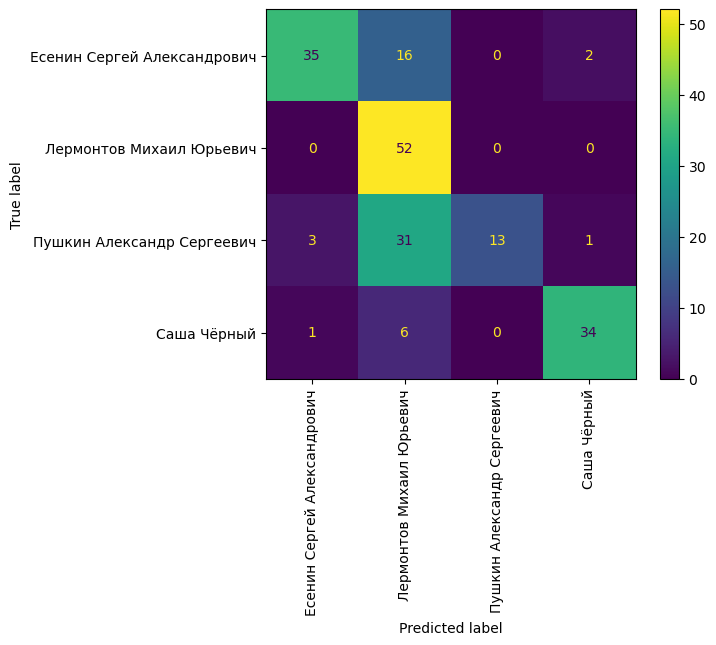

In [37]:
report(nb)

                             precision    recall  f1-score   support

Есенин Сергей Александрович       0.85      0.83      0.84        53
   Лермонтов Михаил Юрьевич       0.84      0.81      0.82        52
 Пушкин Александр Сергеевич       0.74      0.71      0.72        48
                Саша Чёрный       0.80      0.90      0.85        41

                   accuracy                           0.81       194
                  macro avg       0.81      0.81      0.81       194
               weighted avg       0.81      0.81      0.81       194



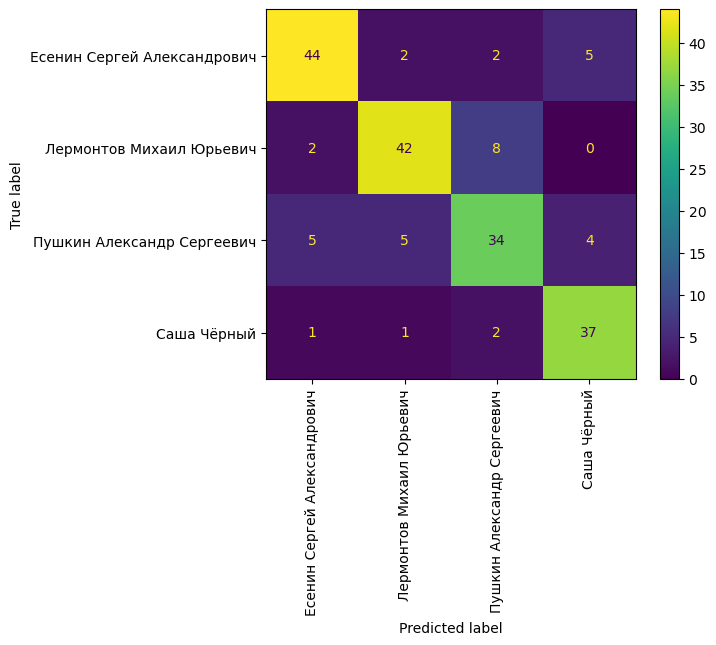

In [38]:
report(log_model)

                             precision    recall  f1-score   support

Есенин Сергей Александрович       0.84      0.72      0.78        53
   Лермонтов Михаил Юрьевич       0.89      0.75      0.81        52
 Пушкин Александр Сергеевич       0.69      0.75      0.72        48
                Саша Чёрный       0.70      0.90      0.79        41

                   accuracy                           0.77       194
                  macro avg       0.78      0.78      0.77       194
               weighted avg       0.79      0.77      0.77       194



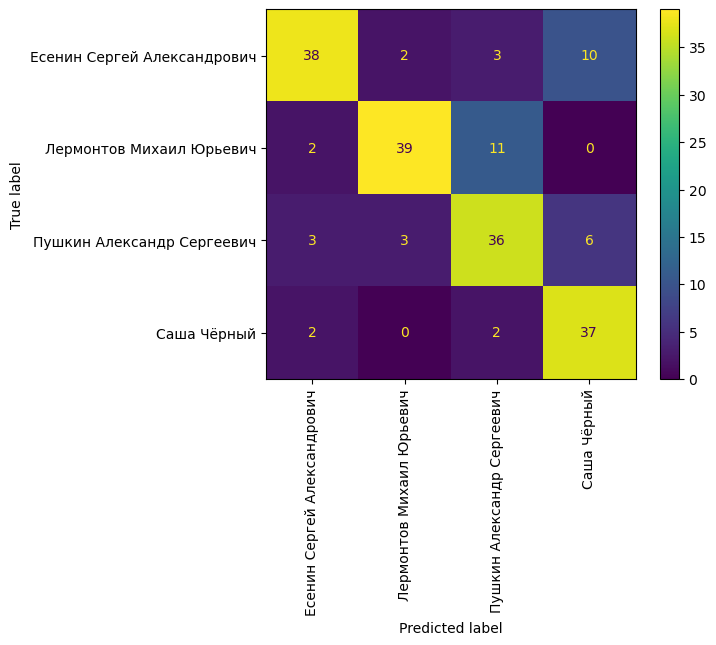

In [39]:
report(rbf_svc)

                             precision    recall  f1-score   support

Есенин Сергей Александрович       0.83      0.83      0.83        53
   Лермонтов Михаил Юрьевич       0.81      0.81      0.81        52
 Пушкин Александр Сергеевич       0.73      0.69      0.71        48
                Саша Чёрный       0.82      0.88      0.85        41

                   accuracy                           0.80       194
                  macro avg       0.80      0.80      0.80       194
               weighted avg       0.80      0.80      0.80       194



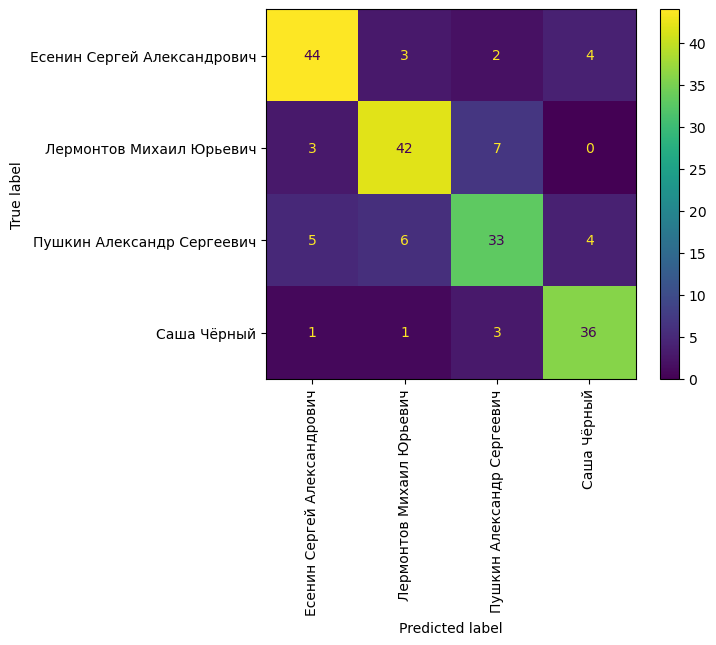

In [40]:
report(linear_svc)

## Логистическая регрессия демонстрирует наилучшую точность

In [41]:
from sklearn.pipeline import Pipeline

In [42]:
pipeline = Pipeline([('tfidf', TfidfVectorizer()), ('svc', LogisticRegression())])

In [43]:
pipeline.fit(df['text'], df['writer'])

Pipeline(steps=[('tfidf', TfidfVectorizer()), ('svc', LogisticRegression())])

In [44]:
df['text'][245]

'Расстались мы; но твой портрет\nЯ на груди моей храню:\nКак бледный призрак лучших лет,\nОн душу радует мою.\nИ новым преданный страстям,\nЯ разлюбить его не мог:\nТак храм оставленный – всё храм,\nКумир поверженный – всё бог!\n1837 г.\n\xa0\n'

In [45]:
df.iloc[244]['writer']

'Лермонтов Михаил Юрьевич'

## Введу данные и сделаю предсказание

In [46]:
pipeline.predict(['Расстались мы; но твой портрет\nЯ на груди моей храню:\nКак бледный призрак лучших лет,\nОн душу радует мою.\nИ новым преданный страстям,\nЯ разлюбить его не мог:\nТак храм оставленный – всё храм,\nКумир поверженный – всё бог!\n1837 г.\n\xa0\n'])

array(['Лермонтов Михаил Юрьевич'], dtype=object)